In [1]:
!pip install torch torchvision torchmetrics matplotlib scikit-learn tqdm seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import os
from PIL import Image

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
data_dir = "cotton"

img_size = 224
batch_size = 16

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
class_names = dataset.classes
num_classes = len(class_names)

train_size = int(0.7 * len(dataset))
val_size   = int(0.2 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_set, val_set, test_set = torch.utils.data.random_split(dataset, [train_size,val_size,test_size])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("Train =", len(train_set))
print("Val =", len(val_set))
print("Test =", len(test_set))
print("Classes:", class_names)

Train = 1197
Val = 342
Test = 171
Classes: ['bacterial_blight', 'curl_virus', 'fussarium_wilt', 'healthy']


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

for p in resnet.parameters(): p.requires_grad = False
for p in densenet.parameters(): p.requires_grad = False

resnet_feature_size = resnet.fc.in_features
densenet_feature_size = densenet.classifier.in_features

resnet.fc = nn.Identity()
densenet.classifier = nn.Identity()

resnet.to(device)
densenet.to(device)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\aksha/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%
0.4%

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\aksha/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100.0%


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
class FusionNet(nn.Module):
    def __init__(self, f1, f2, num_classes):
        super().__init__()
        self.m1 = f1
        self.m2 = f2
        self.fc = nn.Sequential(
            nn.Linear(resnet_feature_size + densenet_feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self,x):
        f1 = self.m1(x)
        f2 = self.m2(x)
        fused = torch.cat([f1, f2], dim=1)
        return self.fc(fused)

model = FusionNet(resnet,densenet,num_classes).to(device)
model

FusionNet(
  (m1): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0005)

epochs = 15
train_losses, val_losses, val_accs = [], [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for imgs,labels in tqdm(train_loader):
        imgs,labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out,labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    val_loss = 0
    with torch.no_grad():
        for imgs,labels in val_loader:
            imgs,labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out,labels)
            val_loss += loss.item()
            preds = torch.argmax(out,1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)

    acc = correct/total
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    val_accs.append(acc)

    print(f"Epoch {epoch+1}/{epochs}  Train Loss={train_losses[-1]:.3f}  Val Loss={val_losses[-1]:.3f}  Val Acc={acc:.3f}")


100%|██████████| 75/75 [02:35<00:00,  2.08s/it]


Epoch 1/15  Train Loss=0.758  Val Loss=0.267  Val Acc=0.921


100%|██████████| 75/75 [02:15<00:00,  1.81s/it]


Epoch 2/15  Train Loss=0.330  Val Loss=0.170  Val Acc=0.947


100%|██████████| 75/75 [01:58<00:00,  1.58s/it]


...

Epoch 13/15  Train Loss=0.074  Val Loss=0.032  Val Acc=0.982


100%|██████████| 75/75 [01:59<00:00,  1.59s/it]


Epoch 14/15  Train Loss=0.136  Val Loss=0.050  Val Acc=0.988


100%|██████████| 75/75 [01:58<00:00,  1.57s/it]


Epoch 15/15  Train Loss=0.100  Val Loss=0.049  Val Acc=0.985


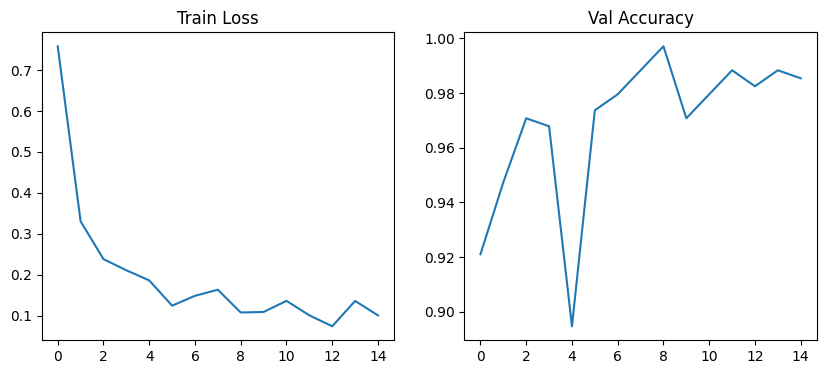

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title("Train Loss")
plt.subplot(1,2,2); plt.plot(val_accs); plt.title("Val Accuracy")
plt.show()


In [ ]:
model.eval()
correct,total = 0,0
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs,labels in test_loader:
        imgs,labels = imgs.to(device), labels.to(device)
        out = model(imgs)
        preds = torch.argmax(out,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)
        all_preds += preds.cpu().numpy().tolist()
        all_labels += labels.cpu().numpy().tolist()

acc = correct/total
print("Test Accuracy =", acc*100)
print(classification_report(all_labels, all_preds, target_names=class_names))


Test Accuracy = 98.83040935672514
                  precision    recall  f1-score   support

bacterial_blight       1.00      1.00      1.00        47
      curl_virus       1.00      0.97      0.99        40
  fussarium_wilt       0.98      1.00      0.99        43
         healthy       0.98      0.98      0.98        41

        accuracy                           0.99       171
       macro avg       0.99      0.99      0.99       171
    weighted avg       0.99      0.99      0.99       171



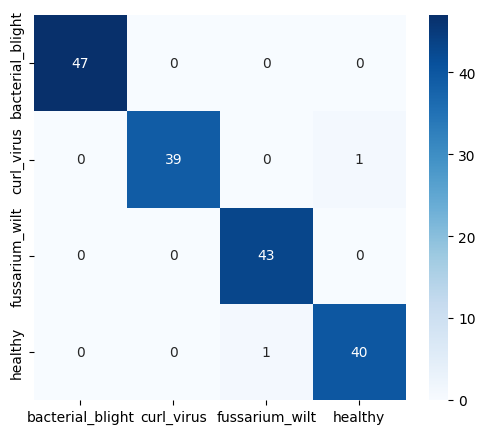

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.show()


In [ ]:
def predict_image(path):
    img = Image.open(path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out = model(img_t)
        pred = torch.argmax(out,1).item()
    return class_names[pred]

print(predict_image(r"D:\S6 mini project\file\cotton\bacterial_blight\bact111.jpg"))
print(predict_image(r"D:\S6 mini project\file\cotton\curl_virus\Curl181.png"))
print(predict_image(r"D:\S6 mini project\file\cotton\fussarium_wilt\fus294.jpg"))
print(predict_image(r"D:\S6 mini project\file\cotton\healthy\h156.jpg"))

bacterial_blight
curl_virus
fussarium_wilt
healthy


In [ ]:
torch.save(model.state_dict(), "cotton_model.pth")